<a href="https://colab.research.google.com/github/Thiago89ml/Sesgos-de-Palabras/blob/main/Noticias_Espa%C3%B1olas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('df_total.csv')

In [ ]:
!pip install gensim

import gensim
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     1217 non-null   object
 1   news    1217 non-null   object
 2   Type    1217 non-null   object
dtypes: object(3)
memory usage: 28.7+ KB


In [ ]:
df.head(50)

,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra
5,https://www.larepublica.co/redirect/post/3225281,El emprendimiento del sector inmobiliario Rent...,Alianzas
6,https://www.bbva.com/es/mx/mexico-y-el-desafio...,El país tiene pendiente generar más y mejores ...,Macroeconomia
7,https://www.bbva.com/es/podcast-agile-en-la-un...,En el 'podcast' tenemos el placer de entrevist...,Innovacion
8,https://www.bbva.com/es/la-ingenieria-social-e...,"El factor humano, normalmente identificado com...",Innovacion
9,https://www.bbva.com/es/que-hace-un-developer-...,Los perfiles que se demandan en un banco han e...,Innovacion


In [ ]:
dfnews = df['news']

In [ ]:

corpus = dfnews.tolist()

In [ ]:
sentences= [frase.lower().split() for frase in corpus]

print(sentences[0])

['durante', 'el', 'foro', 'la', 'banca', 'articulador', 'empresarial', 'para', 'el', 'desarrollo', 'sostenible', 'el', 'director', 'de', 'sostenibilidad', 'y', 'clientes', 'globales', 'de', 'bbva', 'en', 'colombia', 'andrés', 'garcía', 'aseguró', 'que', 'es', 'importante', 'entender', 'que', 'la', 'sostenibilidad', 'no', 'la', 'podemos', 'asociar', 'a', 'mayores', 'costos.', 'yo', 'creo', 'que', 'el', 'no', 'tener', 'un', 'concepto', 'de', 'negocio', 'sostenible', 'puede', 'tener', 'un', 'mayor', 'impacto', 'de', 'lo', 'que', 'imaginamos.para', 'garcía', 'el', 'reto', 'más', 'importante', 'es', 'no', 'cambiar', 'prioridades', 'ni', 'que', 'compitan', 'entre', 'sí', 'necesariamente.', 'en', 'muchos', 'de', 'los', 'casos', 'se', 'debe', 'tratar', 'de', 'mantener', 'la', 'prioridad', 'en', 'cuanto', 'a', 'la', 'ambición', 'de', 'negocios', 'más', 'sostenibles', 'un', 'reto', 'enorme', 'por', 'la', 'coyuntura.', 'la', 'sostenibilidad', 'nos', 'abre', 'oportunidades', 'a', 'mejores', 'fuent

In [ ]:
model = Word2Vec(
    sentences,
    vector_size=60,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

print(model.wv["estudiante"])
print(len(model.wv["estudiante"]))  # debería dar 50

[-1.24737255e-01  1.13806747e-01  2.58209407e-01  9.06273499e-02
 -1.44382760e-01  2.99606938e-02  1.20981671e-01  3.03777426e-01
 -8.66390169e-02 -1.55331135e-01  1.90102607e-01  1.29901469e-01
  6.11806512e-02 -9.44585279e-02 -5.67534305e-02 -1.06203549e-01
  1.14656724e-01  9.10630077e-03 -1.05976835e-01 -5.88082150e-02
  8.21823552e-02 -1.99546665e-01 -3.25232558e-02  2.02633560e-01
 -3.78740504e-02  1.49245381e-01  1.41616929e-02  1.36704013e-01
 -1.06485642e-01 -3.58051136e-02  1.68367736e-02 -2.30141133e-01
  7.34680444e-02  2.33881830e-04  1.55539036e-01  1.56802207e-01
  5.30406693e-03 -1.96059242e-01 -2.57569969e-01 -6.29976168e-02
 -3.49848010e-02 -5.36023639e-02 -1.80182606e-01 -6.35954738e-02
 -9.95427445e-02 -1.18094966e-01 -1.71044935e-02  8.80977884e-03
 -1.60395622e-01  2.98674285e-01  2.53228247e-02 -7.01667601e-03
 -1.41887158e-01  1.64336458e-01  4.17732857e-02  1.47739649e-01
  8.44259858e-02 -1.70232728e-02  1.90036133e-01 -3.08213502e-01]
60


In [ ]:
palabras_a_graficar = [
    'prometedor',
    "esfuerzo",
    "costoso",
    'calidad',
    'extranjero',
    'habitante',
    'cantidad',
    'viable',
    'deficiente'




]

palabras_validas = [p for p in palabras_a_graficar if p in model.wv]
print("Palabras que se van a graficar:", palabras_validas)

Palabras que se van a graficar: ['prometedor', 'esfuerzo', 'costoso', 'calidad', 'extranjero', 'habitante', 'cantidad', 'viable', 'deficiente']


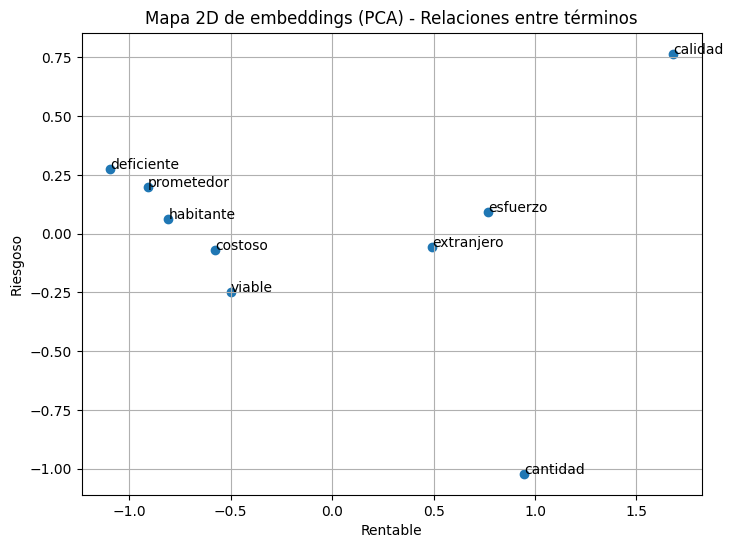

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

vectores = [model.wv[p] for p in palabras_validas]

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(vectores)

plt.figure(figsize=(8,6))

x_vals = coords_2d[:, 0]
y_vals = coords_2d[:, 1]

plt.scatter(x_vals, y_vals)

for i, palabra in enumerate(palabras_validas):
    plt.annotate(palabra, (x_vals[i], y_vals[i]))

plt.title("Mapa 2D de embeddings (PCA) - Relaciones entre términos")
plt.xlabel("Rentable")
plt.ylabel("Riesgoso")
plt.grid(True)
plt.show()